<a href="https://colab.research.google.com/github/Unsa15120/ExData_Plotting1/blob/master/NOC_Delay_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Required Libraries

In [13]:
#!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

print("Libraries imported successfully")

Libraries imported successfully


#Uploading NOC Data.xlsx into Colab

In [14]:
from google.colab import files
uploaded = files.upload()

Saving noc_data.xlsx to noc_data (1).xlsx


#Loading Data into a dataframe

In [15]:
df = pd.read_excel('noc_data.xlsx')

print("Data loaded successfully")

Data loaded successfully


#Data Exploration

###Dataset Shape (Rows, Columns)

In [16]:
print("Dataset Shape:", df.shape)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape: (3200, 6)
Number of rows: 3200
Number of columns: 6


###Column Names

In [17]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Received \nDate', 'Outgoing Date', 'Interface', 'NOC Type', 'interface stage', 'Processing_Days']


###Data Types of Each Column

In [18]:
print("Data Types:")
print(df.dtypes)

Data Types:
Received \nDate    datetime64[ns]
Outgoing Date      datetime64[ns]
Interface                  object
NOC Type                   object
interface stage            object
Processing_Days             int64
dtype: object


###Preview First and Last Rows

In [19]:
print("First 10 rows:")
display(df.head(10))
print()
print("Last 10 rows:")
display(df.tail(10))

First 10 rows:


,Received \nDate,Outgoing Date,Interface,NOC Type,interface stage,Processing_Days
0,2020-01-02,2020-01-02,Conflict,design noc,Operational,0
1,2020-01-05,2020-01-05,Conflict,design noc,Under Construction,0
2,2020-01-05,2020-05-19,Conflict,design noc,Under Construction,135
3,2020-01-05,2020-04-02,Conflict,design noc,Under Construction,88
4,2020-01-06,2020-01-06,Conflict,design noc,Under Construction,0
5,2020-01-06,2020-01-14,Conflict,design noc,Under Design,8
6,2020-01-06,2020-02-19,Conflict,design noc,Under Construction,44
7,2020-01-08,2020-02-05,Conflict,design noc,Under Construction,28
8,2020-01-08,2020-01-22,Conflict,design noc,Under Construction,14
9,2020-01-12,2020-03-03,Conflict,design noc,Under Construction,51



Last 10 rows:


,Received \nDate,Outgoing Date,Interface,NOC Type,interface stage,Processing_Days
3190,2023-06-20,2023-07-01,No Conflict,information noc,Under Construction,11
3191,2020-09-17,2021-01-09,Conflict,design noc,Under Construction,114
3192,2023-04-28,2023-05-24,Conflict,route approval,Under Construction,26
3193,2020-10-25,2021-12-28,Conflict,design noc,Under Construction,429
3194,2020-07-28,2020-09-21,Conflict,design noc,Under Construction,55
3195,2026-03-18,2026-04-16,Conflict,information noc,Under Construction,29
3196,2020-04-23,2020-05-30,Conflict,design noc,Under Construction,37
3197,2020-08-02,2020-09-29,Conflict,design noc,Under Construction,58
3198,2023-04-17,2023-06-14,Conflict,design noc,Under Construction,58
3199,2023-11-05,2024-02-19,Conflict,design noc,Under Construction,106


###Check Missing Values Per Column

In [20]:
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Received \nDate    0
Outgoing Date      0
Interface          0
NOC Type           0
interface stage    0
Processing_Days    0
dtype: int64


###Check for Duplicate Rows

In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


###Summary Statistics for Numeric Columns

In [22]:
print("Summary Statistics (Numeric Columns):")
display(df.describe())

Summary Statistics (Numeric Columns):


,Received \nDate,Outgoing Date,Processing_Days
count,3200,3200,3200.000000
mean,2022-07-11 01:27:18,2022-08-15 07:22:21.000000256,35.246563
min,2019-08-24 00:00:00,2019-09-19 00:00:00,0.000000
25%,2021-04-15 18:00:00,2021-05-14 12:00:00,14.000000
50%,2022-07-26 00:00:00,2022-08-30 00:00:00,25.000000
75%,2023-06-20 00:00:00,2023-08-04 00:00:00,43.000000
max,2026-05-28 00:00:00,2026-06-22 00:00:00,557.000000
std,NaN,NaN,39.465499


###Unique Values Count for Each Column

In [23]:
print("Unique Values Per Column:")
print(df.nunique())

Unique Values Per Column:
Received \nDate    1267
Outgoing Date      1309
Interface             2
NOC Type              5
interface stage       3
Processing_Days     189
dtype: int64


###Value Counts for Categorical Columns

In [24]:
print("Interface value counts:")
print(df['Interface'].value_counts(dropna=False))
print()
print("NOC Type value counts:")
print(df['NOC Type'].value_counts(dropna=False))
print()
print("interface stage value counts:")
print(df['interface stage'].value_counts(dropna=False))

Interface value counts:
Interface
Conflict       2479
No Conflict     721
Name: count, dtype: int64

NOC Type value counts:
NOC Type
information noc     1272
design noc           892
construction noc     722
trial trench noc     262
route approval        52
Name: count, dtype: int64

interface stage value counts:
interface stage
Under Construction    2025
Under Design           906
Operational            269
Name: count, dtype: int64


#SLA/KPI Threshold & Label Creation

###Set SLA Threshold by Interface Type

In [25]:
sla_rules = {
    'Conflict': 14,
    'No Conflict': 3
}

print("SLA Rules applied:")
print(sla_rules)

SLA Rules applied:
{'Conflict': 14, 'No Conflict': 3}


###Create the Target Label (Delayed / On-Time)

In [26]:
def get_sla_status(row):
    threshold = sla_rules[row['Interface']]
    return 'Delayed' if row['Processing_Days'] > threshold else 'On-Time'

df['SLA_Status'] = df.apply(get_sla_status, axis=1)

print("Label created successfully")
print()
print("SLA_Status value counts:")
print(df['SLA_Status'].value_counts())

Label created successfully

SLA_Status value counts:
SLA_Status
Delayed    2584
On-Time     616
Name: count, dtype: int64


###Check Label Balance (%)

In [27]:
print("SLA_Status distribution (%):")
print(df['SLA_Status'].value_counts(normalize=True) * 100)

SLA_Status distribution (%):
SLA_Status
Delayed    80.75
On-Time    19.25
Name: proportion, dtype: float64


###Check Label Balance by Interface Type

In [28]:
print("SLA_Status breakdown by Interface:")
print(df.groupby('Interface')['SLA_Status'].value_counts())

SLA_Status breakdown by Interface:
Interface    SLA_Status
Conflict     Delayed       1971
             On-Time        508
No Conflict  Delayed        613
             On-Time        108
Name: count, dtype: int64


#Exploratory Data Analysis (EDA)



In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

###Overall Delayed vs On-Time Split

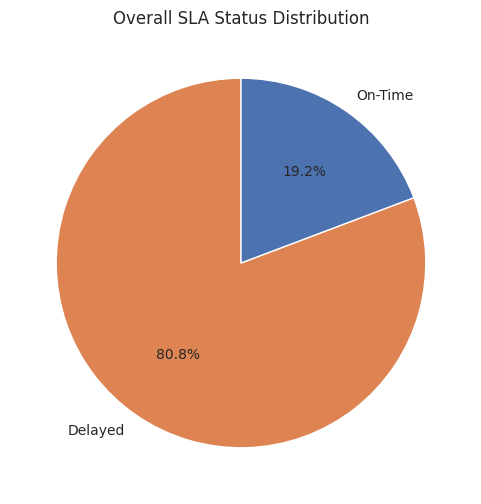

In [30]:
plt.figure(figsize=(6, 6))
df['SLA_Status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#DD8452', '#4C72B0'], startangle=90
)
plt.title('Overall SLA Status Distribution')
plt.ylabel('')
plt.show()

###Delay Rate by NOC Type

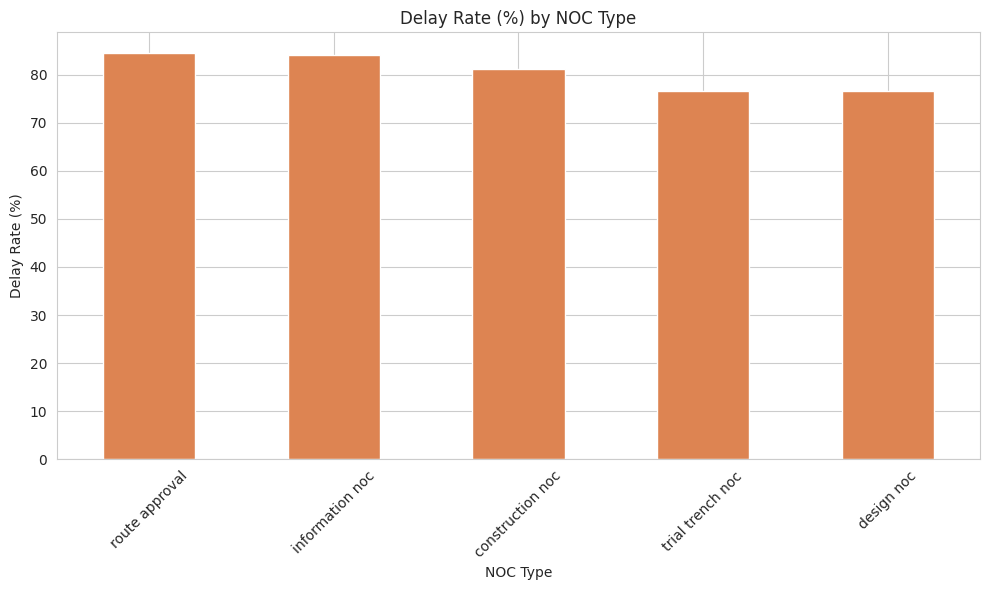

NOC Type
route approval      84.615385
information noc     84.040881
construction noc    81.301939
trial trench noc    76.717557
design noc          76.569507
Name: SLA_Status, dtype: float64


In [31]:
delay_by_noc = df.groupby('NOC Type')['SLA_Status'].apply(
    lambda x: (x == 'Delayed').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
delay_by_noc.plot(kind='bar', color='#DD8452')
plt.title('Delay Rate (%) by NOC Type')
plt.ylabel('Delay Rate (%)')
plt.xlabel('NOC Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(delay_by_noc)

###Delay Rate by Interface (Conflict vs No Conflict)

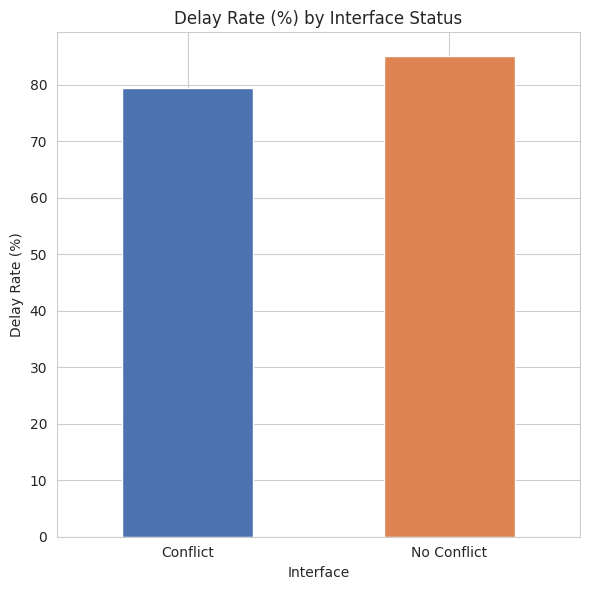

Interface
Conflict       79.507866
No Conflict    85.020804
Name: SLA_Status, dtype: float64


In [32]:
delay_by_interface = df.groupby('Interface')['SLA_Status'].apply(
    lambda x: (x == 'Delayed').mean() * 100
)

plt.figure(figsize=(6, 6))
delay_by_interface.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Delay Rate (%) by Interface Status')
plt.ylabel('Delay Rate (%)')
plt.xlabel('Interface')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(delay_by_interface)

###Delay Rate by Interface Stage

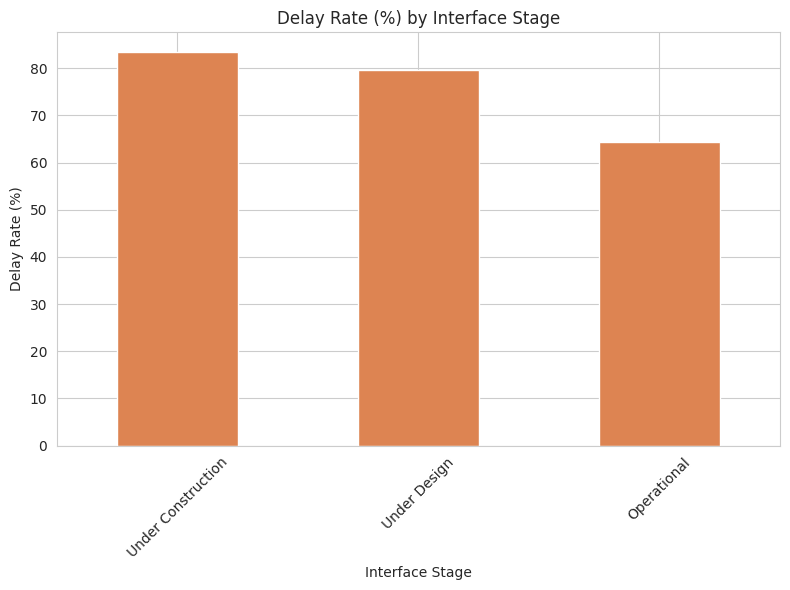

interface stage
Under Construction    83.456790
Under Design          79.580574
Operational           64.312268
Name: SLA_Status, dtype: float64


In [33]:
delay_by_stage = df.groupby('interface stage')['SLA_Status'].apply(
    lambda x: (x == 'Delayed').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
delay_by_stage.plot(kind='bar', color='#DD8452')
plt.title('Delay Rate (%) by Interface Stage')
plt.ylabel('Delay Rate (%)')
plt.xlabel('Interface Stage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(delay_by_stage)

###Processing Days Distribution (with Both SLA Thresholds)

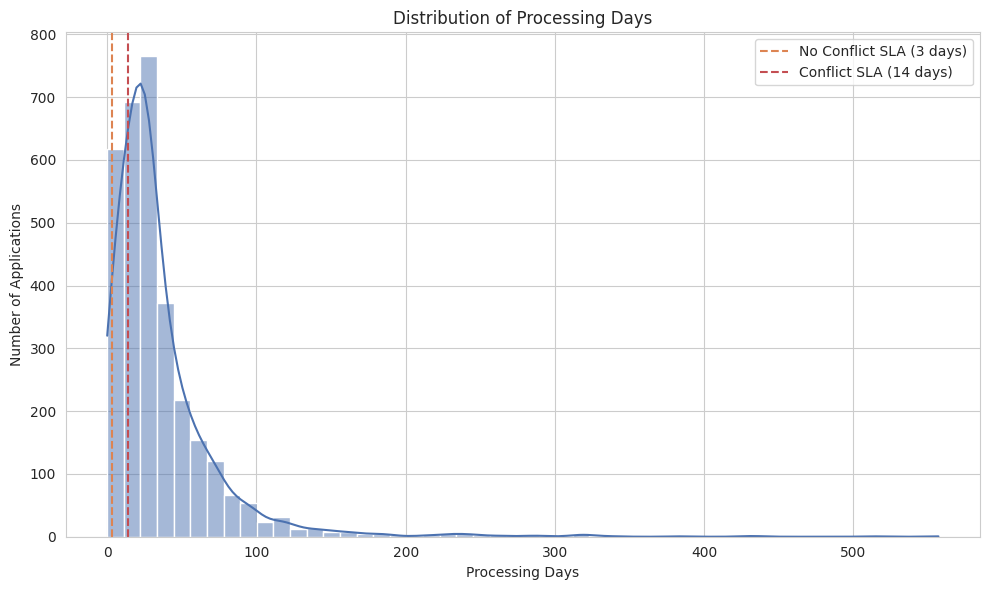

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Processing_Days'], bins=50, kde=True, color='#4C72B0')
plt.axvline(3, color='#DD8452', linestyle='--', label='No Conflict SLA (3 days)')
plt.axvline(14, color='#C44E52', linestyle='--', label='Conflict SLA (14 days)')
plt.title('Distribution of Processing Days')
plt.xlabel('Processing Days')
plt.ylabel('Number of Applications')
plt.legend()
plt.tight_layout()
plt.show()

###Processing Days by NOC Type (Boxplot)

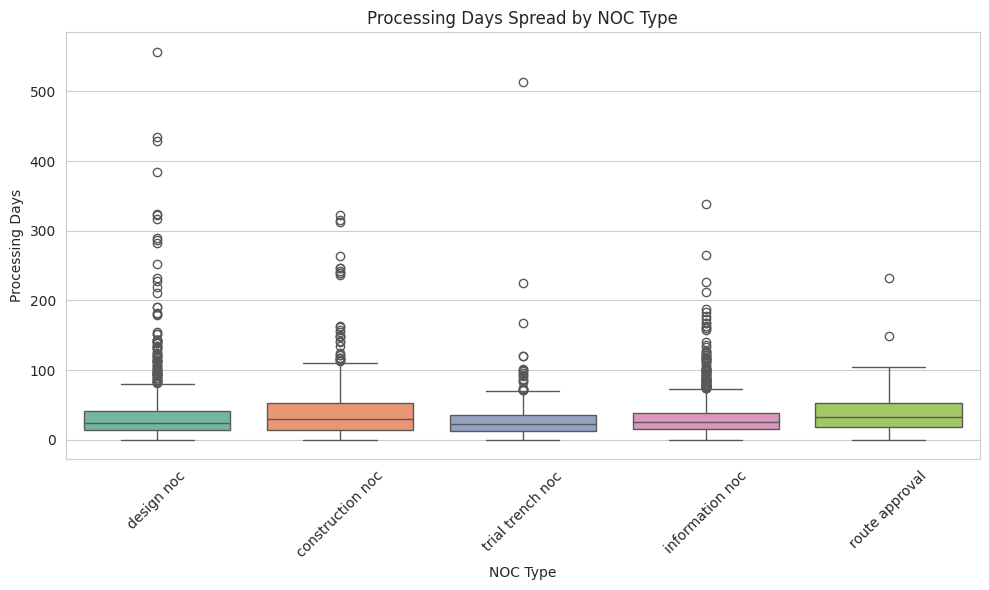

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='NOC Type', y='Processing_Days', hue='NOC Type', palette='Set2', legend=False)
plt.title('Processing Days Spread by NOC Type')
plt.xlabel('NOC Type')
plt.ylabel('Processing Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Delay Trend Over Time (by Year)

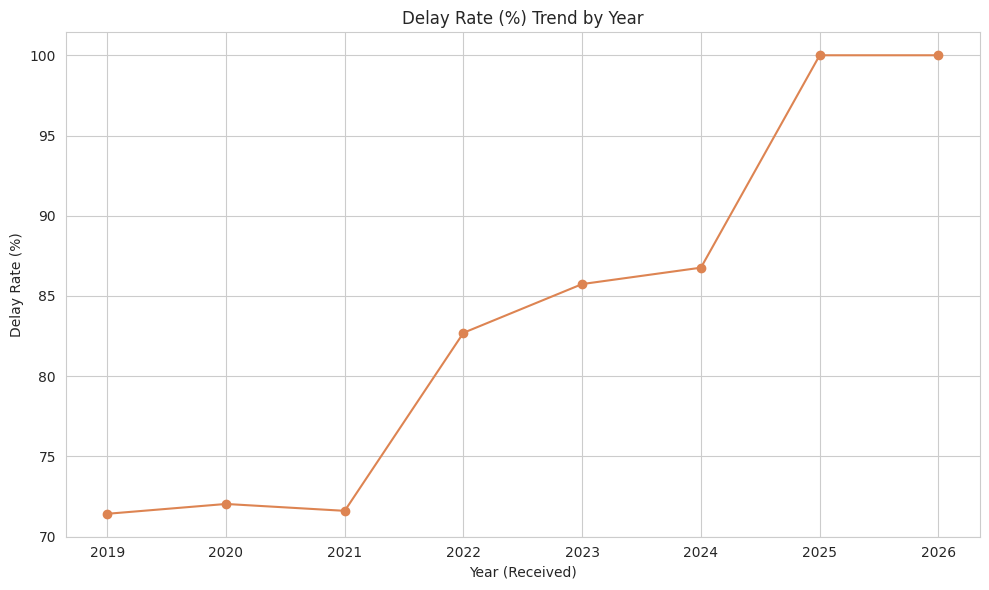

Received_Year
2019     71.428571
2020     72.041166
2021     71.612903
2022     82.705718
2023     85.743381
2024     86.764706
2025    100.000000
2026    100.000000
Name: SLA_Status, dtype: float64


In [36]:
df['Received_Year'] = df['Received \nDate'].dt.year

delay_by_year = df.groupby('Received_Year')['SLA_Status'].apply(
    lambda x: (x == 'Delayed').mean() * 100
)

plt.figure(figsize=(10, 6))
delay_by_year.plot(kind='line', marker='o', color='#DD8452')
plt.title('Delay Rate (%) Trend by Year')
plt.xlabel('Year (Received)')
plt.ylabel('Delay Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(delay_by_year)

###Combined Heatmap NOC Type vs Interface Stage

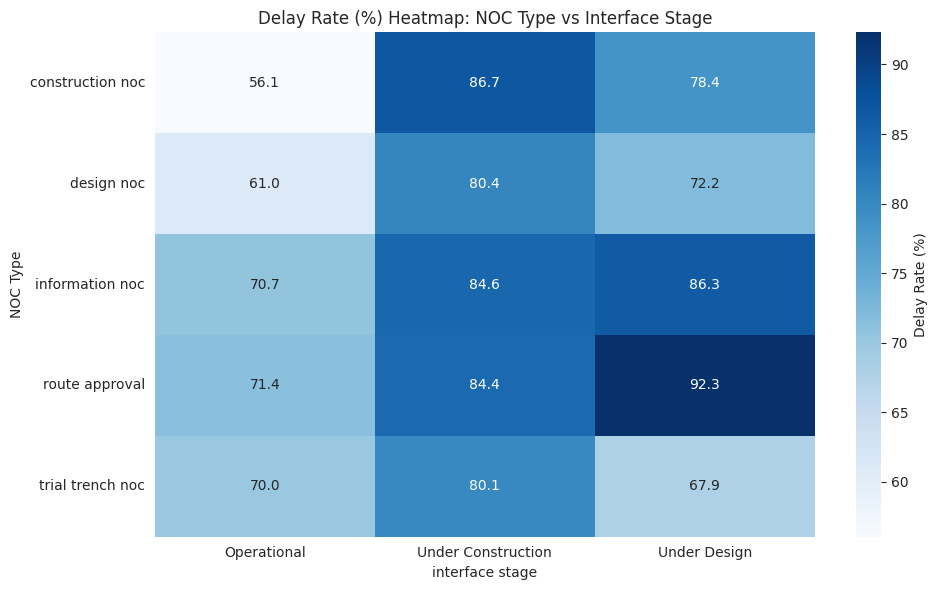

In [37]:
pivot_table = df.pivot_table(
    values='SLA_Status',
    index='NOC Type',
    columns='interface stage',
    aggfunc=lambda x: (x == 'Delayed').mean() * 100
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Delay Rate (%)'})
plt.title('Delay Rate (%) Heatmap: NOC Type vs Interface Stage')
plt.tight_layout()
plt.show()

#Feature Engineering

###Extract Date-Based Features

In [38]:
df['Received_Year'] = df['Received \nDate'].dt.year
df['Received_Month'] = df['Received \nDate'].dt.month
df['Received_Weekday'] = df['Received \nDate'].dt.dayofweek

print("New date-based features created:")
df[['Received \nDate', 'Received_Year', 'Received_Month', 'Received_Weekday']].head(10)

New date-based features created:


,Received \nDate,Received_Year,Received_Month,Received_Weekday
0,2020-01-02,2020,1,3
1,2020-01-05,2020,1,6
2,2020-01-05,2020,1,6
3,2020-01-05,2020,1,6
4,2020-01-06,2020,1,0
5,2020-01-06,2020,1,0
6,2020-01-06,2020,1,0
7,2020-01-08,2020,1,2
8,2020-01-08,2020,1,2
9,2020-01-12,2020,1,6


###Encode Categorical Columns

In [39]:
df_encoded = pd.get_dummies(df, columns=['Interface', 'NOC Type', 'interface stage'], drop_first=True)

print("Categorical columns encoded")
print("New shape:", df_encoded.shape)
df_encoded.head(10)

Categorical columns encoded
New shape: (3200, 14)


,Received \nDate,Outgoing Date,Processing_Days,SLA_Status,Received_Year,Received_Month,Received_Weekday,Interface_No Conflict,NOC Type_design noc,NOC Type_information noc,NOC Type_route approval,NOC Type_trial trench noc,interface stage_Under Construction,interface stage_Under Design
0,2020-01-02,2020-01-02,0,On-Time,2020,1,3,False,True,False,False,False,False,False
1,2020-01-05,2020-01-05,0,On-Time,2020,1,6,False,True,False,False,False,True,False
2,2020-01-05,2020-05-19,135,Delayed,2020,1,6,False,True,False,False,False,True,False
3,2020-01-05,2020-04-02,88,Delayed,2020,1,6,False,True,False,False,False,True,False
4,2020-01-06,2020-01-06,0,On-Time,2020,1,0,False,True,False,False,False,True,False
5,2020-01-06,2020-01-14,8,On-Time,2020,1,0,False,True,False,False,False,False,True
6,2020-01-06,2020-02-19,44,Delayed,2020,1,0,False,True,False,False,False,True,False
7,2020-01-08,2020-02-05,28,Delayed,2020,1,2,False,True,False,False,False,True,False
8,2020-01-08,2020-01-22,14,On-Time,2020,1,2,False,True,False,False,False,True,False
9,2020-01-12,2020-03-03,51,Delayed,2020,1,6,False,True,False,False,False,True,False


###Encode Target Variable (SLA_Status)

In [40]:
df_encoded['SLA_Status'] = df_encoded['SLA_Status'].map({'On-Time': 0, 'Delayed': 1})

print("Target variable encoded (On-Time = 0, Delayed = 1)")
df_encoded[['SLA_Status']].value_counts()

Target variable encoded (On-Time = 0, Delayed = 1)


,count
SLA_Status,
1,2584
0,616


###Select Final Features for Model

In [41]:
drop_cols = ['Received \nDate', 'Outgoing Date', 'SLA_Status', 'Processing_Days']
X = df_encoded.drop(columns=drop_cols)
y = df_encoded['SLA_Status']

print("Feature columns (X):")
print(X.columns.tolist())
print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature columns (X):
['Received_Year', 'Received_Month', 'Received_Weekday', 'Interface_No Conflict', 'NOC Type_design noc', 'NOC Type_information noc', 'NOC Type_route approval', 'NOC Type_trial trench noc', 'interface stage_Under Construction', 'interface stage_Under Design']

X shape: (3200, 10)
y shape: (3200,)


#Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-test split completed")
print()
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()
print("y_train distribution:")
print(y_train.value_counts(normalize=True) * 100)
print()
print("y_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train-test split completed

X_train shape: (2560, 10)
X_test shape: (640, 10)
y_train shape: (2560,)
y_test shape: (640,)

y_train distribution:
SLA_Status
1    80.742188
0    19.257812
Name: proportion, dtype: float64

y_test distribution:
SLA_Status
1    80.78125
0    19.21875
Name: proportion, dtype: float64


#Handle Class Imbalance (SMOTE)

In [43]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("SMOTE applied successfully")
print()
print("Before SMOTE y_train distribution:")
print(y_train.value_counts())
print()
print("After SMOTE y_train_resampled distribution:")
print(y_train_resampled.value_counts())

SMOTE applied successfully

Before SMOTE y_train distribution:
SLA_Status
1    2067
0     493
Name: count, dtype: int64

After SMOTE y_train_resampled distribution:
SLA_Status
1    2067
0    2067
Name: count, dtype: int64


#Baseline Model Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_resampled, y_train_resampled)


y_pred_log = log_model.predict(X_test)


log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression trained successfully")
print()
print("Baseline Accuracy:", round(log_accuracy * 100, 2), "%")

Logistic Regression trained successfully

Baseline Accuracy: 62.03 %


#Advanced Models Random Forest & XGBoost

In [45]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)


xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("Random Forest trained successfully")
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print()
print("XGBoost trained successfully")
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")

Random Forest trained successfully
Random Forest Accuracy: 68.91 %

XGBoost trained successfully
XGBoost Accuracy: 67.5 %


#Model Comparison & Evaluation

In [46]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)

models = {
    'Logistic Regression': y_pred_log,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

results = []

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })

results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     62.03      82.16   67.70     74.23
1        Random Forest     68.91      85.18   74.47     79.46
2              XGBoost     67.50      83.66   74.27     78.69


###Confusion Matrix for Each Model

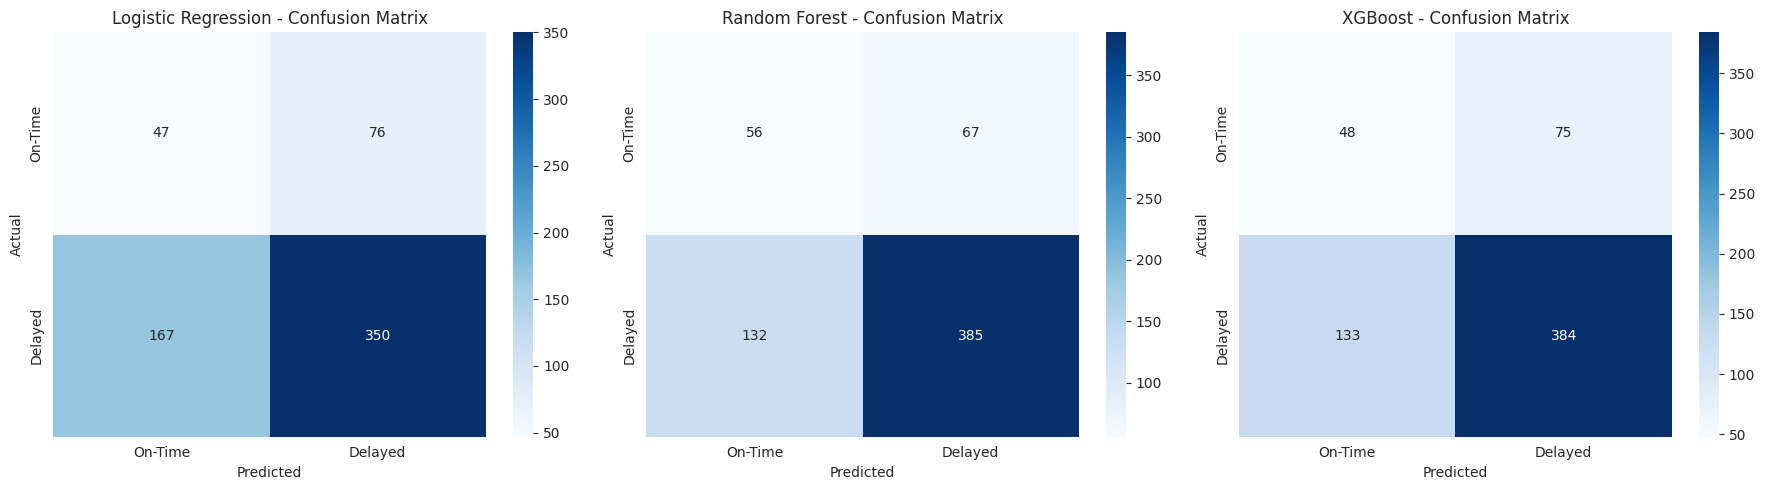

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['On-Time', 'Delayed'], yticklabels=['On-Time', 'Delayed'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

###ROC-AUC Score for Each Model

In [48]:
roc_log = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])
roc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print("ROC-AUC Scores:")
print("Logistic Regression:", round(roc_log, 3))
print("Random Forest:", round(roc_rf, 3))
print("XGBoost:", round(roc_xgb, 3))

ROC-AUC Scores:
Logistic Regression: 0.56
Random Forest: 0.668
XGBoost: 0.665


###Detailed Classification Report

In [49]:
for name, y_pred in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))


Logistic Regression
              precision    recall  f1-score   support

     On-Time       0.22      0.38      0.28       123
     Delayed       0.82      0.68      0.74       517

    accuracy                           0.62       640
   macro avg       0.52      0.53      0.51       640
weighted avg       0.71      0.62      0.65       640


Random Forest
              precision    recall  f1-score   support

     On-Time       0.30      0.46      0.36       123
     Delayed       0.85      0.74      0.79       517

    accuracy                           0.69       640
   macro avg       0.57      0.60      0.58       640
weighted avg       0.75      0.69      0.71       640


XGBoost
              precision    recall  f1-score   support

     On-Time       0.27      0.39      0.32       123
     Delayed       0.84      0.74      0.79       517

    accuracy                           0.68       640
   macro avg       0.55      0.57      0.55       640
weighted avg       0.73      

#Feature Importance (Initial Model)

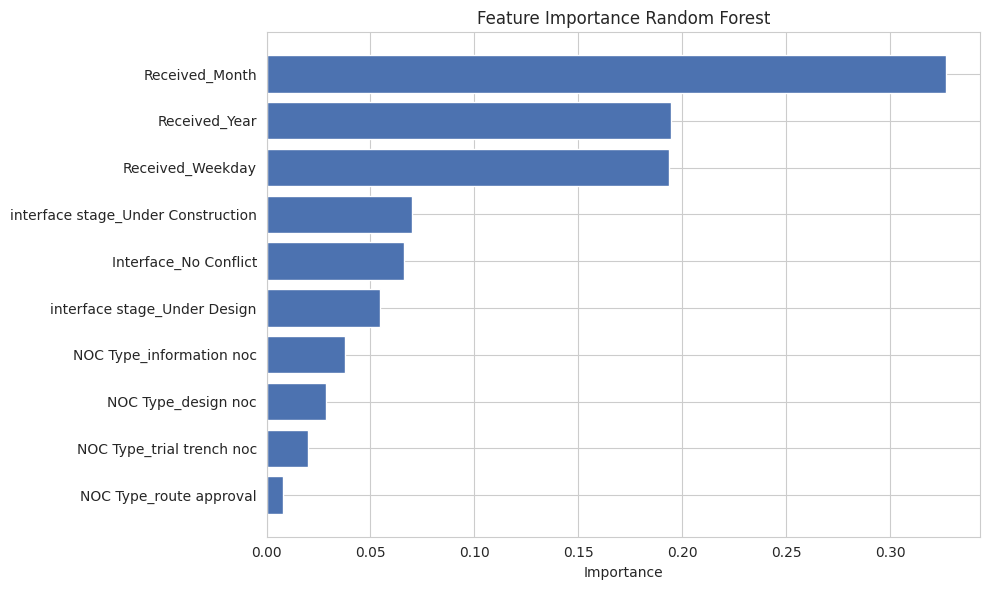

                              Feature  Importance
1                      Received_Month    0.326989
0                       Received_Year    0.194508
2                    Received_Weekday    0.193478
8  interface stage_Under Construction    0.069841
3               Interface_No Conflict    0.066299
9        interface stage_Under Design    0.054343
5            NOC Type_information noc    0.037896
4                 NOC Type_design noc    0.028622
7           NOC Type_trial trench noc    0.019980
6             NOC Type_route approval    0.008044


In [50]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#4C72B0')
plt.xlabel('Importance')
plt.title('Feature Importance Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df)

#Model Improvement

###Hyperparameter Tuning Random Forest

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_resampled, y_train_resampled)

print("Best parameters found:")
print(rf_grid.best_params_)
print()

best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_best_rf)
tuned_f1 = f1_score(y_test, y_pred_best_rf)
tuned_roc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print("Tuned Random Forest Accuracy:", round(tuned_accuracy * 100, 2), "%")
print("Tuned Random Forest F1-Score:", round(tuned_f1 * 100, 2), "%")
print("Tuned Random Forest ROC-AUC:", round(tuned_roc, 3))

Best parameters found:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Random Forest Accuracy: 69.53 %
Tuned Random Forest F1-Score: 79.92 %
Tuned Random Forest ROC-AUC: 0.669


###Create Combined Feature (NOC Type + Interface Stage)

In [52]:
df['NOC_Stage_Combo'] = df['NOC Type'] + '_' + df['interface stage']

print("Combined feature created:")
print(df['NOC_Stage_Combo'].value_counts())

Combined feature created:
NOC_Stage_Combo
information noc_Under Construction     800
design noc_Under Construction          578
construction noc_Under Construction    429
information noc_Under Design           373
design noc_Under Design                237
construction noc_Under Design          227
trial trench noc_Under Construction    186
information noc_Operational             99
design noc_Operational                  77
construction noc_Operational            66
trial trench noc_Under Design           56
route approval_Under Construction       32
trial trench noc_Operational            20
route approval_Under Design             13
route approval_Operational               7
Name: count, dtype: int64


###Re-encode Data with Combined Feature

In [53]:
df_encoded2 = pd.get_dummies(
    df,
    columns=['Interface', 'NOC Type', 'interface stage', 'NOC_Stage_Combo'],
    drop_first=True
)

df_encoded2['SLA_Status'] = df_encoded2['SLA_Status'].map({'On-Time': 0, 'Delayed': 1})

drop_cols2 = ['Received \nDate', 'Outgoing Date', 'SLA_Status', 'Processing_Days']
X2 = df_encoded2.drop(columns=drop_cols2)
y2 = df_encoded2['SLA_Status']

print("New feature set shape:", X2.shape)
print()
print(X2.columns.tolist())

New feature set shape: (3200, 24)

['Received_Year', 'Received_Month', 'Received_Weekday', 'Interface_No Conflict', 'NOC Type_design noc', 'NOC Type_information noc', 'NOC Type_route approval', 'NOC Type_trial trench noc', 'interface stage_Under Construction', 'interface stage_Under Design', 'NOC_Stage_Combo_construction noc_Under Construction', 'NOC_Stage_Combo_construction noc_Under Design', 'NOC_Stage_Combo_design noc_Operational', 'NOC_Stage_Combo_design noc_Under Construction', 'NOC_Stage_Combo_design noc_Under Design', 'NOC_Stage_Combo_information noc_Operational', 'NOC_Stage_Combo_information noc_Under Construction', 'NOC_Stage_Combo_information noc_Under Design', 'NOC_Stage_Combo_route approval_Operational', 'NOC_Stage_Combo_route approval_Under Construction', 'NOC_Stage_Combo_route approval_Under Design', 'NOC_Stage_Combo_trial trench noc_Operational', 'NOC_Stage_Combo_trial trench noc_Under Construction', 'NOC_Stage_Combo_trial trench noc_Under Design']


###Split, SMOTE, and Retrain Random Forest with New Features

In [54]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

smote2 = SMOTE(random_state=42)
X2_train_resampled, y2_train_resampled = smote2.fit_resample(X2_train, y2_train)

rf_model2 = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5, min_samples_leaf=1, random_state=42
)
rf_model2.fit(X2_train_resampled, y2_train_resampled)

y2_pred_rf = rf_model2.predict(X2_test)

accuracy2 = accuracy_score(y2_test, y2_pred_rf)
f1_2 = f1_score(y2_test, y2_pred_rf)
roc2 = roc_auc_score(y2_test, rf_model2.predict_proba(X2_test)[:, 1])

print("Results WITH combined feature (NOC_Stage_Combo):")
print("Accuracy:", round(accuracy2 * 100, 2), "%")
print("F1-Score:", round(f1_2 * 100, 2), "%")
print("ROC-AUC:", round(roc2, 3))

Results WITH combined feature (NOC_Stage_Combo):
Accuracy: 70.94 %
F1-Score: 81.02 %
ROC-AUC: 0.681


###Try LightGBM with Combined Feature (for comparison)

In [55]:
!pip install lightgbm --quiet

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X2_train_resampled, y2_train_resampled)

y2_pred_lgbm = lgbm_model.predict(X2_test)

lgbm_accuracy = accuracy_score(y2_test, y2_pred_lgbm)
lgbm_f1 = f1_score(y2_test, y2_pred_lgbm)
lgbm_roc = roc_auc_score(y2_test, lgbm_model.predict_proba(X2_test)[:, 1])

print("LightGBM Results WITH combined feature:")
print("Accuracy:", round(lgbm_accuracy * 100, 2), "%")
print("F1-Score:", round(lgbm_f1 * 100, 2), "%")
print("ROC-AUC:", round(lgbm_roc, 3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2067, number of negative: 2067
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 65
[LightGBM] [Info] Number of data points in the train set: 4134, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Results WITH combined feature:
Accuracy: 67.03 %
F1-Score: 77.86 %
ROC-AUC: 0.66


###Final Model Selection

In [56]:
print("FINAL MODEL COMPARISON:")
print("Logistic Regression       Accuracy: 62.03%, F1: 74.23%, ROC-AUC: 0.560")
print("Random Forest (tuned)     Accuracy: 69.53%, F1: 79.92%, ROC-AUC: 0.669")
print("Random Forest + Combo     Accuracy: 70.94%, F1: 81.02%, ROC-AUC: 0.681 FINAL MODEL")
print("LightGBM + Combo          Accuracy: 67.03%, F1: 77.86%, ROC-AUC: 0.660")
print()
print("Selected Final Model: Random Forest (tuned + combined feature) rf_model2")

FINAL MODEL COMPARISON:
Logistic Regression       Accuracy: 62.03%, F1: 74.23%, ROC-AUC: 0.560
Random Forest (tuned)     Accuracy: 69.53%, F1: 79.92%, ROC-AUC: 0.669
Random Forest + Combo     Accuracy: 70.94%, F1: 81.02%, ROC-AUC: 0.681 FINAL MODEL
LightGBM + Combo          Accuracy: 67.03%, F1: 77.86%, ROC-AUC: 0.660

Selected Final Model: Random Forest (tuned + combined feature) rf_model2


#Feature Importance (Final Model)

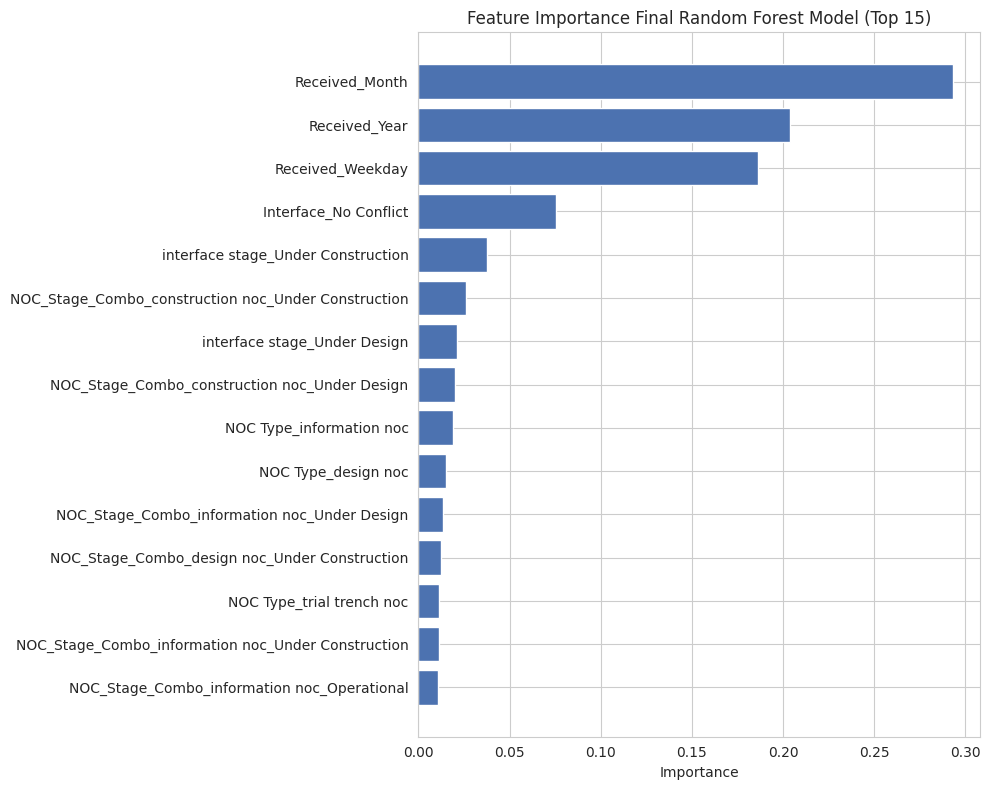

                                              Feature  Importance
1                                      Received_Month    0.293320
0                                       Received_Year    0.204013
2                                    Received_Weekday    0.186118
3                               Interface_No Conflict    0.075567
8                  interface stage_Under Construction    0.037421
10  NOC_Stage_Combo_construction noc_Under Constru...    0.026169
9                        interface stage_Under Design    0.020945
11      NOC_Stage_Combo_construction noc_Under Design    0.020319
5                            NOC Type_information noc    0.018736
4                                 NOC Type_design noc    0.015266
17       NOC_Stage_Combo_information noc_Under Design    0.013620
13      NOC_Stage_Combo_design noc_Under Construction    0.012629
7                           NOC Type_trial trench noc    0.011295
16  NOC_Stage_Combo_information noc_Under Construc...    0.011119
15        

In [57]:
importances2 = rf_model2.feature_importances_
feature_names2 = X2.columns

importance_df2 = pd.DataFrame({
    'Feature': feature_names2,
    'Importance': importances2
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_df2['Feature'][:15], importance_df2['Importance'][:15], color='#4C72B0')
plt.xlabel('Importance')
plt.title('Feature Importance Final Random Forest Model (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df2)

#Saving the Final Model

In [58]:
import pickle


with open('noc_delay_prediction_model.pkl', 'wb') as f:
    pickle.dump(rf_model2, f)

with open('model_features.pkl', 'wb') as f:
    pickle.dump(list(X2.columns), f)

print("Model saved successfully as 'noc_delay_prediction_model.pkl'")
print("Feature list saved successfully as 'model_features.pkl'")

Model saved successfully as 'noc_delay_prediction_model.pkl'
Feature list saved successfully as 'model_features.pkl'


In [59]:
from google.colab import files
files.download('noc_delay_prediction_model.pkl')
files.download('model_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>